# STATISTICAL ANALYSIS
- Making hypothesis and testing the claim

## Load the data
- Here I load the pickle file that was saved in step1

In [17]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
# We load the pickle file so we have the correct data type

df = pd.read_pickle('data_MPG_clean.pkl')

In [19]:
# print 10 sample values

print(df.sample(10))

           mpg  cylinders  displacement  horsepower  weight  acceleration  \
306  28.796875          6           173         115    2595     11.296875   
260  18.593750          6           225         110    3620     18.703125   
20   25.000000          4           110          87    2672     17.500000   
161  16.000000          6           250         105    3897     18.500000   
332  29.796875          4            89          62    1845     15.296875   
273  23.906250          4           119          97    2405     14.898438   
219  25.500000          4           122          96    2300     15.500000   
384  32.000000          4            91          67    1965     15.703125   
267  27.500000          4           134          95    2560     14.203125   
36   19.000000          6           250          88    3302     15.500000   

     model_year  origin  
306          79     usa  
260          78     usa  
20           70  europe  
161          75     usa  
332          80  europ

In [20]:
print(df.describe())

              mpg   cylinders  displacement  horsepower       weight  \
count  398.000000  398.000000    398.000000  398.000000   398.000000   
mean    23.515625    5.454774    193.424623  104.462312  2970.424623   
std      7.816406    1.701004    104.271000   38.199230   846.841774   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.500000    4.000000    104.250000   76.000000  2223.750000   
50%     23.000000    4.000000    148.500000   95.000000  2803.500000   
75%     29.000000    8.000000    262.000000  125.000000  3608.000000   
max     46.593750    8.000000    455.000000  230.000000  5140.000000   

       acceleration  model_year  
count    398.000000  398.000000  
mean      15.570312   76.010050  
std        2.757812    3.697627  
min        8.000000   70.000000  
25%       13.822266   73.000000  
50%       15.500000   76.000000  
75%       17.175781   79.000000  
max       24.796875   82.000000  


In [21]:
# lets see data types and memory usage

print(df.info(memory_usage="deep"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   mpg           398 non-null    float16 
 1   cylinders     398 non-null    uint8   
 2   displacement  398 non-null    int16   
 3   horsepower    398 non-null    uint8   
 4   weight        398 non-null    int16   
 5   acceleration  398 non-null    float16 
 6   model_year    398 non-null    int8    
 7   origin        398 non-null    category
dtypes: category(1), float16(2), int16(2), int8(1), uint8(2)
memory usage: 5.0 KB
None


In [22]:
# Memory usage of each column in Bytes

print(df.memory_usage())

Index           128
mpg             796
cylinders       398
displacement    796
horsepower      398
weight          796
acceleration    796
model_year      398
origin          422
dtype: int64


# Simple Hypothesis Testing

### Problem (One-sample t-test)
- We are given a sample of vehicles with a **sample mean** MPG of 23.5. Determine whether the **population mean** MPG is significantly different from 25 at a **significance level of α = 0.05**.

### Hypothesis (MOST IMPORTANT)
- **Null hypothesis (H0)**: The true average MPG = 25
- **Alternative hypothesis (H1)**: The true average MPG is NOT 25

This is a two-tailed test.


#### Definition
**p_value**: Probability of observing this statistic if the null hypothesis is true

### Prompt used for AI to generate above code:


I have miles per gallon data. The output of print(df.describe()) is given by following:
```
              mpg   cylinders  displacement  horsepower       weight  \
count  398.000000  398.000000    398.000000  398.000000   398.000000   
mean    23.515625    5.454774    193.424623  104.462312  2970.424623   
std      7.816406    1.701004    104.271000   38.199230   846.841774   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.500000    4.000000    104.250000   76.000000  2223.750000   
50%     23.000000    4.000000    148.500000   95.000000  2803.500000   
75%     29.000000    8.000000    262.000000  125.000000  3608.000000   
max     46.593750    8.000000    455.000000  230.000000  5140.000000   

       acceleration  model_year  
count    398.000000  398.000000  
mean      15.570312   76.010050  
std        2.757812    3.697627  
min        8.000000   70.000000  
25%       13.822266   73.000000  
50%       15.500000   76.000000  
75%       17.175781   79.000000  
max       24.796875   82.000000 
```


### PROMPT to solve above Problem statement. 
We are given a sample of vehicles with a sample mean MPG of 23.5. Determine whether the population mean MPG is significantly different from 25 at a significance level of α = 0.05. 

Give me code to answer above question

In [23]:
# step1: Get the sample 

sample = df['mpg']

print("Sample Mean:", sample.mean())
print("Size of sample:", len(sample))

Sample Mean: 23.52
Size of sample: 398


Here since:

- Population standard deviation is unknown
- Sample size = 398
- Data is numerical and approximately normal (large n)

We will use One-sample t-test is appropriate

In [24]:
# step2) This is 1 sample. Calculate p_value
from scipy.stats import ttest_1samp

mu_0 = 25 # # Hypothesized population mean
t_stat, p_value = ttest_1samp(sample, mu_0)

print("T-statistics:", t_stat)
print("p_value     :", p_value)

T-statistics: -3.7887553982737807
p_value     : 0.00017486688036184858


## What the p-value actually means
### The p-value is the probability of observing a sample mean this far away(or farther) from true mean (25)  if the true mean really were 25.

In [25]:
# step3: Decide

alpha = 0.05

if p_value < alpha:
    print("Reject H0: Average MPG is significantly different from 25")
else:
    print("Fail to reject H0: No significant difference from 25")

Reject H0: Average MPG is significantly different from 25


## Report
There is strong statistical evidence to conclude that the population mean MPG is significantly different from 25 MPG at the 5% significance level.

The negative t-statistic indicates that the sample mean MPG is lower than 25 MPG, suggesting that the true population mean MPG is likely less than 25.

## Two-sample t-test

### Question: 
- Determine whether the average MPG (miles per gallon) differs between vehicles manufactured in the USA and Japan. To answer this question, perform a hypothesis test at a **significance level of α = 0.05**.

A two-tailed independent two-sample t-test at α = 0.05 would be used to test whether the mean MPG of USA-manufactured cars differs from that of Japan-manufactured cars.

### Define the hypothesis (MOST IMPORTANT)
- **Null hypothesis (H0)**: The true average MPG of USA = true average MPG of Japan cars.
- **Alternative hypothesis (H1)**: The true average MPG of USA and Japan cars is not same.

This is a two-tailed test.

### Prompt used for AI to generate above code:

I have miles per gallon data. The output of print(df.describe()) is given by following:
```
              mpg   cylinders  displacement  horsepower       weight  \
count  398.000000  398.000000    398.000000  398.000000   398.000000   
mean    23.515625    5.454774    193.424623  104.462312  2970.424623   
std      7.816406    1.701004    104.271000   38.199230   846.841774   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.500000    4.000000    104.250000   76.000000  2223.750000   
50%     23.000000    4.000000    148.500000   95.000000  2803.500000   
75%     29.000000    8.000000    262.000000  125.000000  3608.000000   
max     46.593750    8.000000    455.000000  230.000000  5140.000000   

       acceleration  model_year  
count    398.000000  398.000000  
mean      15.570312   76.010050  
std        2.757812    3.697627  
min        8.000000   70.000000  
25%       13.822266   73.000000  
50%       15.500000   76.000000  
75%       17.175781   79.000000  
max       24.796875   82.000000 
```

### Problem statement. 
Determine whether the average MPG (miles per gallon) differs between vehicles manufactured in the USA and Japan. To answer this question, perform a hypothesis test at a significance level of α = 0.05.

Give me code to answer above question

In [26]:
# step1: Display mean, std_dev, count for cars MPG by origin

df.groupby('origin', observed=True)['mpg'].agg(['mean', 'std', 'count'])

# Observ: The sample mean MPG for Japan cars is 30.45 and for USA is 20.08 

,mean,std,count
origin,,,
europe,27.892187,6.725169,70
japan,30.450159,6.089157,79
usa,20.083397,6.402594,249


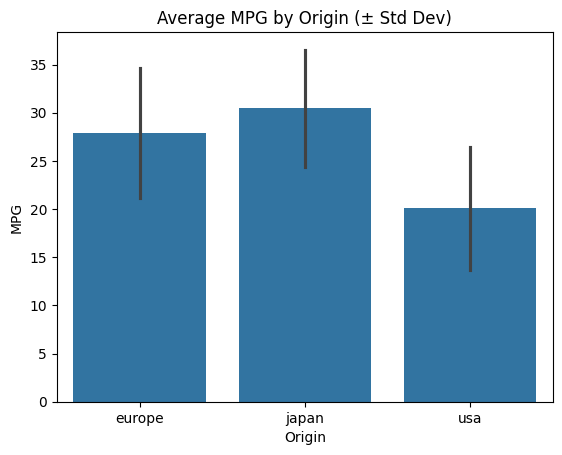

In [27]:
# step2: Let see the average of MPG of cars across origin
sns.barplot(
    data=df,
    x="origin",
    y="mpg",
    errorbar="sd"
)

plt.title("Average MPG by Origin (± Std Dev)")
plt.ylabel("MPG")
plt.xlabel("Origin")
plt.show()

# observ: Japanese cars have high mean MPG.
# The variability , AKA STD_dev, is same for all 3 cars

In [28]:
# step3: calculate the t_stat and p_value (Welch’s t-test)

sample_usa   = df[df['origin'] == 'usa']['mpg']
sample_japan = df[df['origin'] == 'japan']['mpg']

In [29]:
# step4) Look at sample size and variablility
print("Samples of USA  :", sample_usa[:5].to_list())   # first 5 samples only
print("Samples of Japan:", sample_japan[:5].to_list()) # first 5 samples only

print("size of sample_usa  :", len(sample_usa))
print("size of sample_japan:", len(sample_japan))

# USA and Japan vehicle samples:
# - Have different sample sizes
# - Have slighly different MPG variability
# - Therefore, Welch’s t-test (equal_var=False) is the statistically safer choice

Samples of USA  : [18.0, 15.0, 18.0, 16.0, 17.0]
Samples of Japan: [24.0, 27.0, 27.0, 25.0, 31.0]
size of sample_usa  : 249
size of sample_japan: 79


In [30]:
# step5) Find p-value

from scipy.stats import ttest_ind

# here the variance in 2 samples are not same. So, equal_var=False
t_stat, p_value = ttest_ind(sample_usa, sample_japan, equal_var=False)

print("T stat:", t_stat)
print("p_value:", p_value)

T stat: -13.028761327936234
p_value: 9.584021433213985e-26


In [31]:
# step6) Decide

alpha = 0.05

if p_value < alpha:
    print("Reject H0: The true average MPG of USA and Japan cars is not the same.")
else:
    print("Fail to reject H0: The true average MPG of USA and Japan cars statistically not different")

Reject H0: The true average MPG of USA and Japan cars is not the same.


#### Example interpretation:
- USA mean MPG = 20.0
- Japan mean MPG = 30.0
- p-value = 0.0001
 
**Japan cars are significantly more fuel-efficient than USA cars**
  

## Report
A two-sample Welch’s t-test was conducted to compare the mean MPG of cars from the USA and Japan.
The test showed a **statistically significant difference** in mean MPG (**p < 0.05**), with Japanese cars having higher average MPG than US cars.

# One-Way ANOVA

### Question:

- Is the **difference** in average MPG across cars with origin in USA, Japan, Europe **statistically significant** ?
To answer above question use **significance level alpha=0.05**

Here we are checking if MPG are different for USA, Japan and Europe cars. We would perform a one-way Analysis of Variance (ANOVA) at the 5% significance level to test whether there is a statistically significant difference in average MPG across the different origins.


### Hypothesis
- **Null hypothesis (H0)**: Mean MPG of USA =  Mean MPG of Japan = Mean MPG of Europe
- **Alternate hypothesis (H1)**: At least one origin has a different mean MPG

### What ANOVA(Analysis of Variance) checks
- Between-group variance (differences between group means)
- Within-group variance (variation inside each group)

Here we are checking **Between-group variance (differences between group means)**

# Add Variability (Mean + Std)

In [32]:
# step1: Display mean, std_dev, count for cars MPG by origin

df.groupby('origin', observed=True)['mpg'].agg(['mean', 'std', 'count'])

,mean,std,count
origin,,,
europe,27.892187,6.725169,70
japan,30.450159,6.089157,79
usa,20.083397,6.402594,249


# Visual Support (Mean ± Variability)

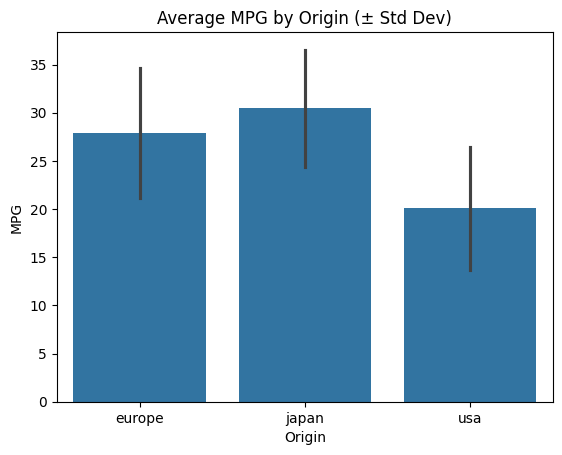

In [33]:
# step2: Show me the visual
sns.barplot(
    data=df,
    x="origin",
    y="mpg",
    errorbar="sd"
)

plt.title("Average MPG by Origin (± Std Dev)")
plt.ylabel("MPG")
plt.xlabel("Origin")
plt.show()

# observ: Japanese cars have high mean MPG.
# The variability , AKA STD_dev, is same for all 3 cars

In [34]:
# step3: compute p_value

from scipy.stats import f_oneway

sample_usa    = df[df['origin'] == 'usa']['mpg']
sample_europe = df[df['origin'] == 'europe']['mpg']
sample_japan  = df[df['origin'] == 'japan']['mpg']
# print(usa)

f_stat, p_value = f_oneway(sample_usa, sample_europe, sample_japan)

print("f_stat:", f_stat)
print("p_value:", p_value)

f_stat: 98.54791489513185
p_value: 1.907681781533859e-35


In [35]:
# step4: Decide

alpha = 0.05

if p_value < alpha:
    print("Reject H0: MPG differs significantly across origins")
else:
    print("Fail to reject H0: No significant difference in MPG")

Reject H0: MPG differs significantly across origins


## Report
Methodology
- We analyzed vehicle MPG data grouped by country of origin.
- A statistical test was conducted using a 5% significance level (α = 0.05).

**Average MPG differs significantly** across USA, Japan, and Europe based cars.

This means the variation in fuel efficiency between these regions is statistically significant and unlikely to be due to chance.

# Correlation Significance Test
### Question
- Is the relationship between **weight and MPG statistically significant** ? To answer above question use **significance level alpha=0.05**.

We are asking whether the observed relationship in the data reflects a real population-level association, or whether it could have occurred by random chance.


### Hypothesis
- **Null hypothesis (H0)**: rho = 0 (no correlation)
- **Alternate hypothesis (H1)**: rho != 0 (there is correlation)

we use simple linear regression (or equivalently, a Pearson correlation test).

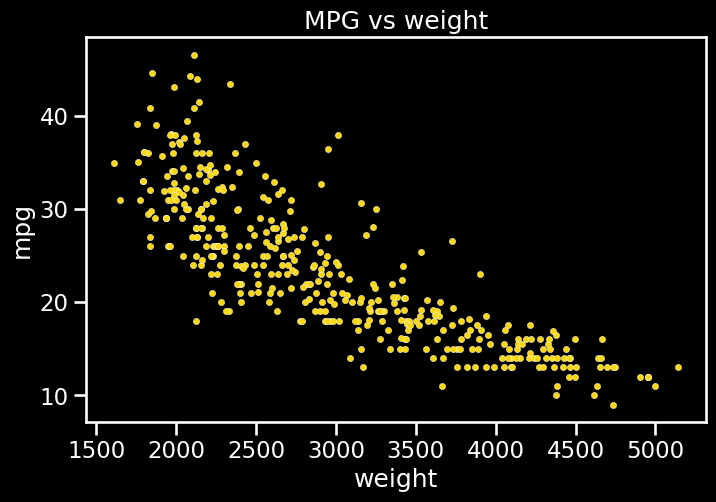

In [36]:
# Step1: Lets use scatter plot  

plt.style.use("dark_background")  
# Optional: control Seaborn palette and font scale
sns.set_palette(["gold"])
sns.set_context("talk")
plt.figure(figsize=(8,5))

col = "weight"

# sns.regplot(data=df, x='horsepower', y='mpg') # Regression line shows trend clearly.
sns.scatterplot(data=df, x=col, y='mpg', s=20)
plt.title(f'MPG vs {col}')
plt.show()

# Observ:
# Downward trend → negative correlation
# Higher weight → lower mpg

In [37]:
# step2: find correlation and p_value

from scipy.stats import pearsonr

X = df['weight'] # independant variable
y = df['mpg']   # dependant variable

stat_, p_value = pearsonr(X, y)

print("stat:", stat_)
print("p_value:", p_value)

stat: -0.8317330158644363
p_value: 2.9980868317410095e-103


In [38]:
# step3: Decide

alpha = 0.05

if p_value < alpha:
    print("Reject H₀: There is correlation")
else:
    print("Fail to reject H₀: ")

Reject H₀: There is correlation


## Report 
At the 5% significance level, there is **strong statistical evidence of a statistically significant linear relationship between weight and MPG.**

As weight increases, MPG decreases on average (heavier cars tend to be less fuel efficient).

# Variance Test

## Question
- Is there a statistically significant difference in MPG **variance** between USA and Japan cars? To answer above question use **significance level alpha=0.05**


### Plain-English
Do USA and Japan cars show similar variability in fuel efficiency?

### Hypothesis
```
- Null Hypothesis (H0)       : Variance of MPG (USA) = Variance of MPG (Japan)
- Alternative Hypothesis (H1): Variances are different
```

In [39]:
# step1: Find variance

sample_usa   = df[df['origin'] == 'usa']['mpg']
sample_japan = df[df['origin'] == 'japan']['mpg']

print("variance for usa  :", sample_usa.var())
print("variance for japan:", sample_japan.var())

# observ: It appears that the variance is significantly different

variance for usa  : 41.0
variance for japan: 37.1


In [40]:
# step2: compute p-value

from scipy.stats import levene

sample_usa   = df[df['origin'] == 'usa']['mpg']
sample_japan = df[df['origin'] == 'japan']['mpg']

stats_, p_value = levene(sample_usa, sample_japan)

print("stat:", stat_)
print("p_value:", p_value)

stat: -0.8317330158644363
p_value: 0.6949774002173181


In [42]:
# step3: Decide

alpha = 0.05

if p_value < alpha:
    print("Reject H0: Variance are not equal")
else:
    print("Fail to reject H0: Not enough evidence to reject H0 ")

Fail to reject H0: Not enough evidence to reject H0 


## Report
At the 5% significance level, **there is no statistically significant evidence that the MPG variance differs between USA and Japan cars** in this dataset.

In other words, their MPG variability appears statistically similar, even though their mean MPG values are quite different.

# Question
Are newer cars (after 1975) more fuel-efficient than older cars?

### Plain English:
Compare average MPG for cars from model years 1976+ vs 1975 and earlier.

**Type of test:** Two-sample t-test (difference in means).

### Hypothesis:
- Null Hypothesis (H0)      : Newer and older cars have the same mean MPG.
- Alternative Hypothesis(H1): Newer cars have higher mean MPG than older cars.

In [43]:
# 1) Split into older (<= 1975) and newer (> 1975)

older = df[df['model_year'] <= 75]['mpg'].dropna()
newer = df[df['model_year'] > 75]['mpg'].dropna()

In [47]:
# Lets print 1st 5 values of above samples:

print("older:", older[:5].to_list())
print("newer:", newer[:5].to_list())

print("mean for older cars:", older.mean())
print("mean for newer cars:", newer.mean())

older: [18.0, 15.0, 18.0, 16.0, 17.0]
newer: [28.0, 25.0, 25.0, 26.0, 27.0]
mean for older cars: 19.42
mean for newer cars: 26.94


In [49]:
# 2) Welch's t-test (does not assume equal variances), one-sided: newer > older

from scipy.stats import ttest_ind

statistic, p_two_sided = ttest_ind(newer, older, equal_var=False)

print("stat    :", statistic)
print("p-values:", p_two_sided)

stat    : 11.129294774685325
p-values: 3.4466412195220305e-25


In [50]:
# 3) Convert to one-sided p-value for alternative: mean_newer > mean_older
if statistic > 0:
    p_one_sided = p_two_sided / 2.0
else:
    p_one_sided = 1.0 - p_two_sided / 2.0

In [51]:
# 4) Decide

alpha = 0.05

if p_one_sided < alpha:
    print("Reject H0: Variance are not equal")
else:
    print("Fail to reject H0: Not enough evidence to reject H0 ")

Reject H0: Variance are not equal


# Report
At the 5% significance level, there is very strong statistical evidence that:

**Newer cars (after 1975) are more fuel-efficient (higher MPG) than older cars (1975 and earlier) in this dataset.**